# CN7031 – Flight Delay 2024 | Big Data Analysis (PySpark)

This notebook runs the **whole** analysis pipeline with PySpark:

1. Load the data (sample or full 1.3 GB file)
2. Understand the dataset (schema, missing values, stats)
3. Clean it (missing / duplicates / outliers / cancelled)
4. Build extra features (season, day-part, distance band, delay bands ...)
5. **Descriptive analysis + lots of charts** (airline, airport, route, month,
   day, hour, season, distance, weekend, red-eye, state, causes, cancellations)
6. **Deeper analysis** (distributions, percentiles, correlations, delay
   propagation, two-way heatmaps, hub/network)
7. **Machine learning** (predict if a flight will be delayed + predict the
   delay minutes)
8. **Clustering** (group airports into performance segments)

All charts are saved to `outputs/figures/`, all tables to `outputs/tables/`.
Interactive **maps** (HTML) are saved to `outputs/figures/` too.

> Tip: keep `USE_SAMPLE = True` to test fast. Set it to `False` for the real
> full-dataset run.

## 0. Setup

In [47]:
import sys, os
import importlib
sys.path.append(os.path.abspath(".."))   # if the notebook is inside notebooks/
sys.path.append(os.path.abspath("."))    # if run from the project root

import pandas as pd
from pyspark.sql import functions as F

from src import (config, data_loader, cleaning, features,
                 analysis, advanced_analysis, modeling, clustering,
                 visualize, maps)
importlib.reload(visualize)
importlib.reload(maps)

USE_SAMPLE = True   #Sample or all the files
pd.set_option("display.max_columns", 50)

In [20]:
def save_table(pdf, name):
    path = config.TABLE_DIR / f"{name}.csv"
    pdf.to_csv(path, index=False)
    print("saved ->", path)
    return pdf

### Start Spark
`config.get_spark()` builds the session. **Keep this** – it contains the manual
fix for the old *"Could not initialize class ByteArrayMethods"* crash (the Java
`--add-opens` flags + Java-17 detection).

In [21]:
spark = config.get_spark(memory="8g")
spark

## 1. Load the data

In [22]:
df_raw = data_loader.load_flights(spark, sample=USE_SAMPLE)
print("rows:", df_raw.count(), "| columns:", len(df_raw.columns))
df_raw.printSchema()

rows: 10000 | columns: 35
root
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day_of_month: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- fl_date: string (nullable = true)
 |-- op_unique_carrier: string (nullable = true)
 |-- op_carrier_fl_num: double (nullable = true)
 |-- origin: string (nullable = true)
 |-- origin_city_name: string (nullable = true)
 |-- origin_state_nm: string (nullable = true)
 |-- dest: string (nullable = true)
 |-- dest_city_name: string (nullable = true)
 |-- dest_state_nm: string (nullable = true)
 |-- crs_dep_time: integer (nullable = true)
 |-- dep_time: double (nullable = true)
 |-- dep_delay: double (nullable = true)
 |-- taxi_out: double (nullable = true)
 |-- wheels_off: double (nullable = true)
 |-- wheels_on: double (nullable = true)
 |-- taxi_in: double (nullable = true)
 |-- crs_arr_time: integer (nullable = true)
 |-- arr_time: double (nullable = true)
 |-- arr_delay: double (nullable = 

In [23]:
df_raw.show(5)

+----+-----+------------+-----------+----------+-----------------+-----------------+------+--------------------+---------------+----+----------------+--------------+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+-----------------+--------+----------------+-------------------+--------+--------+-------------+-------------+---------+--------------+-------------------+
|year|month|day_of_month|day_of_week|   fl_date|op_unique_carrier|op_carrier_fl_num|origin|    origin_city_name|origin_state_nm|dest|  dest_city_name| dest_state_nm|crs_dep_time|dep_time|dep_delay|taxi_out|wheels_off|wheels_on|taxi_in|crs_arr_time|arr_time|arr_delay|cancelled|cancellation_code|diverted|crs_elapsed_time|actual_elapsed_time|air_time|distance|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+------------+-----------+----------+-----------------+-----------------+------+--------------------+---------------+----+-

## 2. Dataset understanding
Before cleaning we look at the data: how many missing values, basic statistics,
and how many duplicate rows there are.

In [24]:
# missing values 
missing = cleaning.missing_value_report(df_raw).toPandas().T
missing.columns = ["null_count"]
missing = missing.sort_values("null_count", ascending=False)
save_table(missing.reset_index().rename(columns={"index":"column"}), "missing_values")
missing.head(15)

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/missing_values.csv


,null_count
cancellation_code,9878
actual_elapsed_time,164
arr_delay,164
air_time,164
wheels_on,127
taxi_in,127
arr_time,127
wheels_off,120
taxi_out,120
dep_delay,116


In [25]:
df_raw.select("dep_delay","arr_delay","distance","air_time","taxi_out").describe().show()

+-------+------------------+-----------------+-----------------+------------------+------------------+
|summary|         dep_delay|        arr_delay|         distance|          air_time|          taxi_out|
+-------+------------------+-----------------+-----------------+------------------+------------------+
|  count|              9884|             9836|            10000|              9836|              9880|
|   mean|13.002428166734116|7.545038633590891|         838.3466|115.44550630337535|17.878643724696357|
| stddev| 53.61481898982362|55.80322302372707|598.5265069037354| 70.73618385445785| 9.773378556897814|
|    min|             -22.0|            -78.0|             31.0|               8.0|               4.0|
|    max|            2011.0|           2014.0|           5095.0|             635.0|             154.0|
+-------+------------------+-----------------+-----------------+------------------+------------------+



In [26]:
#duplicate
total = df_raw.count()
distinct = df_raw.dropDuplicates().count()
print(f"total={total:,}  distinct={distinct:,}  duplicates={total-distinct:,}")

total=10,000  distinct=10,000  duplicates=0


## 3. Cleaning
We clean step by step and print the row count after every step, so we can see
exactly how many rows each rule removes.

In [27]:
steps = [
    ("start",               df_raw),
    ("parse dates",         cleaning.parse_dates(df_raw)),
]
d = cleaning.parse_dates(df_raw)
d = cleaning.drop_duplicates(d);            steps.append(("drop duplicates", d))
d = cleaning.drop_cancelled_and_diverted(d);steps.append(("drop cancelled/diverted", d))
d = cleaning.drop_missing_delays(d);        steps.append(("drop missing delays", d))
d = cleaning.remove_delay_outliers(d);      steps.append(("remove outliers", d))

rows = [(name, df.count()) for name, df in steps]
clean_log = pd.DataFrame(rows, columns=["step","rows"])
clean_log["removed"] = clean_log["rows"].shift(1) - clean_log["rows"]
save_table(clean_log, "cleaning_steps")
clean_log

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/cleaning_steps.csv


,step,rows,removed
0,start,10000,NaN
1,parse dates,10000,0.0
2,drop duplicates,10000,0.0
3,drop cancelled/diverted,9836,164.0
4,drop missing delays,9836,0.0
5,remove outliers,9835,1.0


In [28]:
df_clean = cleaning.clean_flights(df_raw)
print("clean rows:", df_clean.count())

clean rows: 9835


## 4. Feature engineering
Add helpful new columns (delay flags, delay bands, dep hour, day-part, season,
weekend, red-eye, route, distance band, cause flags).

In [29]:
df = features.add_features(df_clean)
# cache because we reuse this dataframe many times below
# caching makes it much faster to reuse the dataframe
df = df.cache()
df.count()
print("columns now:", len(df.columns))
df.select("op_unique_carrier","arr_delay","is_delayed","delay_band",
        "dep_hour","day_part","season","is_weekend","distance_band","route").show(5)

26/06/26 23:44:59 WARN CacheManager: Asked to cache already cached data.


columns now: 55
+-----------------+---------+----------+------------+--------+-----------------+------+----------+-------------------+-------+
|op_unique_carrier|arr_delay|is_delayed|  delay_band|dep_hour|         day_part|season|is_weekend|      distance_band|  route|
+-----------------+---------+----------+------------+--------+-----------------+------+----------+-------------------+-------+
|               DL|      8.0|         0|     On time|       8|   Morning (6-12)|Summer|         1|   Long (1200-2500)|SLC-ORD|
|               DL|      5.0|         0|     On time|       9|   Morning (6-12)|Summer|         1|  Medium (600-1200)|ATL-PVD|
|               NK|    113.0|         1|Major (1-3h)|      12|Afternoon (12-17)|Summer|         1|  Medium (600-1200)|LAS-SEA|
|               OO|      1.0|         0|     On time|       6|   Morning (6-12)|Spring|         0|Very short (<250mi)|SBP-SFO|
|               UA|      4.0|         0|     On time|      10|   Morning (6-12)|Autumn|        

## 5. Experiments, results and visualisation (descriptive)

### 5.1 Delays by airline

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/delays_by_airline.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/delay_by_airline.png
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/airline_dep_vs_arr.png


,op_unique_carrier,flights,avg_arr_delay,avg_dep_delay,delayed_pct,big_delay_pct,early_pct
0,WN,1993,5.99,12.09,21.32,6.02,59.36
1,DL,1443,3.55,9.93,17.46,6.58,65.63
2,AA,1359,14.73,20.49,28.04,11.70,55.33
3,OO,1067,9.12,12.84,19.68,7.69,65.42
4,UA,1015,5.37,12.45,22.27,7.39,63.35
5,YX,426,-3.16,1.80,11.50,3.76,73.71
6,MQ,399,4.89,8.43,19.30,6.27,64.41
7,NK,350,8.47,13.81,24.00,8.57,62.00
8,B6,328,11.41,17.48,26.83,10.67,57.62
9,OH,316,13.57,16.76,26.27,11.71,59.49


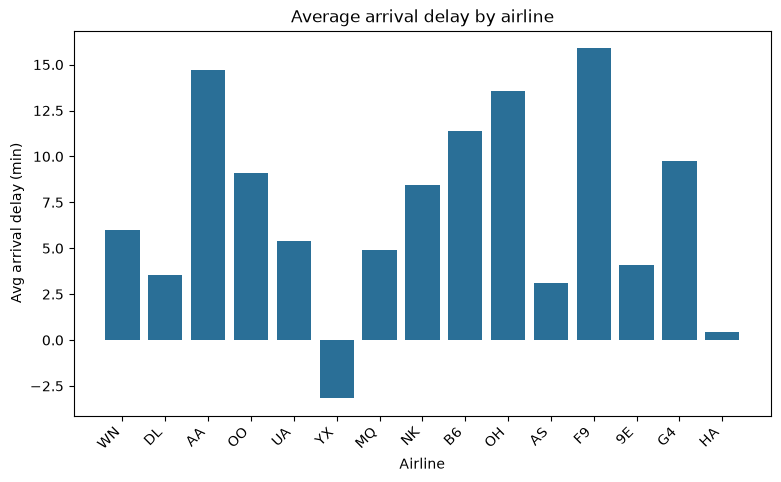

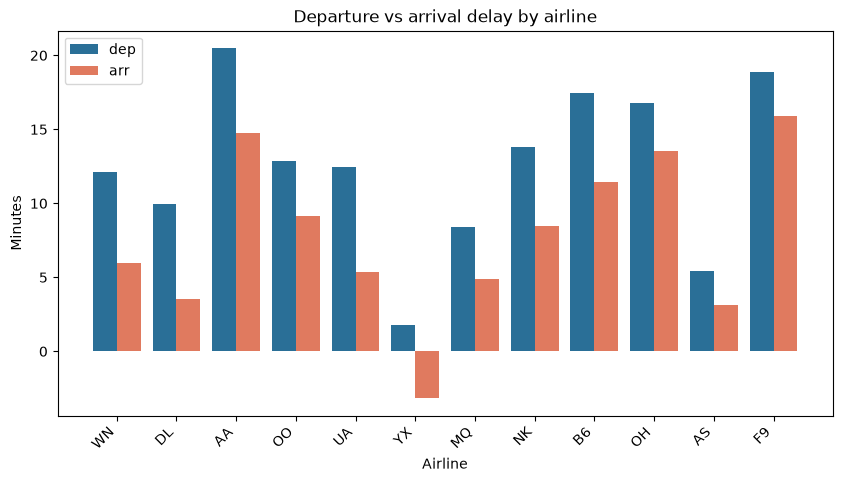

In [30]:
by_airline = analysis.delays_by_airline(df).toPandas()
save_table(by_airline, "delays_by_airline")
visualize.bar_chart(by_airline, "op_unique_carrier", "avg_arr_delay",
    "Average arrival delay by airline", "Airline", "Avg arrival delay (min)",
    "delay_by_airline.png")
visualize.grouped_bar(by_airline.head(12), "op_unique_carrier",
    ["avg_dep_delay","avg_arr_delay"], "Departure vs arrival delay by airline",
    "Airline", "Minutes", "airline_dep_vs_arr.png", labels=["dep","arr"])
by_airline.head(10)

### 5.2 Delays by origin airport + airport bubble MAP

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/delays_by_airport.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/delay_by_airport.png
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/map_airport_bubbles.html
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/map_airport_bubbles.png


,origin,flights,avg_arr_delay,avg_dep_delay,delayed_pct,big_delay_pct,early_pct
0,ATL,487,6.46,10.47,19.71,8.21,65.09
1,DFW,428,13.63,18.80,25.93,10.28,57.01
2,DEN,408,10.15,15.44,27.94,6.86,55.64
3,ORD,387,8.73,14.47,26.36,10.08,58.66
4,CLT,314,15.61,20.56,27.71,11.15,56.37
5,PHX,288,4.82,11.08,20.14,5.56,59.38
6,LAX,278,5.18,11.31,20.50,7.55,64.03
7,LAS,230,8.75,14.10,27.39,7.83,54.35
8,LGA,229,3.91,13.06,17.03,9.61,74.67
9,MCO,221,9.62,13.81,26.24,11.31,55.66


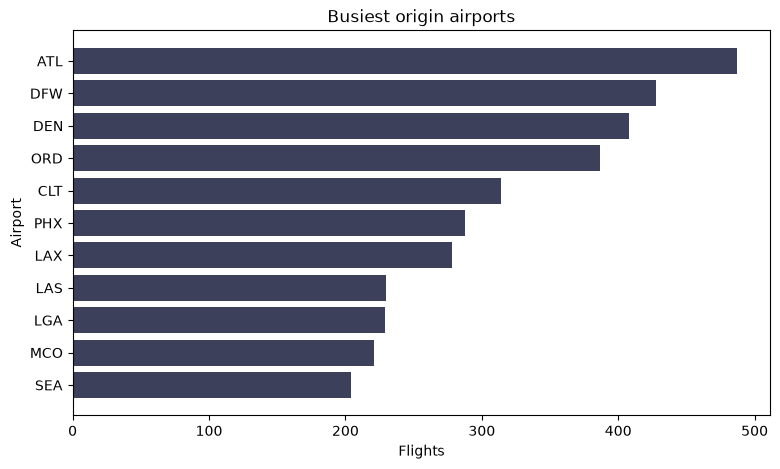

In [31]:
by_airport = analysis.delays_by_origin_airport(df, min_flights=200).toPandas()
save_table(by_airport, "delays_by_airport")
visualize.hbar_chart(by_airport.sort_values("flights", ascending=False),
    "origin", "flights", "Busiest origin airports", "Airport", "Flights",
    "delay_by_airport.png", top=20)
# interactive map: bubble size = flights, colour = avg delay
maps.airport_bubble_map(by_airport, code_col="origin")
by_airport.head(10)

### 5.3 Delays by destination airport

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/delays_by_dest.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/worst_dest_airports.png


,dest,flights,avg_arr_delay,avg_dep_delay,delayed_pct,big_delay_pct,early_pct
0,ATL,479,8.67,15.14,21.09,7.31,64.72
1,DFW,439,13.52,18.03,27.33,11.85,56.49
2,DEN,390,7.02,13.36,19.23,8.46,64.87
3,ORD,365,10.08,15.38,21.92,9.32,64.93
4,CLT,281,8.85,13.04,25.62,9.25,57.30
5,LAS,277,5.66,12.35,21.66,6.50,59.57
6,PHX,274,14.50,18.51,20.80,7.66,55.47
7,LAX,269,2.69,9.03,14.87,4.46,61.34
8,SEA,221,3.08,7.20,18.55,6.79,62.44
9,MCO,211,6.75,13.77,24.64,8.06,59.24


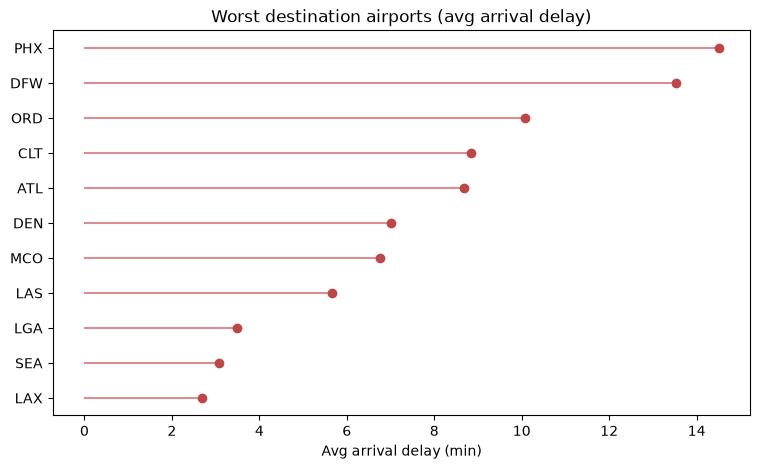

In [32]:
by_dest = analysis.delays_by_dest_airport(df, min_flights=200).toPandas()
save_table(by_dest, "delays_by_dest")
visualize.lollipop_chart(by_dest.sort_values("avg_arr_delay", ascending=False).head(15),
    "dest", "avg_arr_delay", "Worst destination airports (avg arrival delay)",
    "Airport", "Avg arrival delay (min)", "worst_dest_airports.png")
by_dest.head(10)

### 5.4 Busiest routes + route MAP

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/delays_by_route.csv


saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/busiest_routes.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/busiest_routes.png
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/map_routes.html
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/map_routes.png


,origin,dest,route,flights,avg_arr_delay,distance
0,LAX,JFK,LAX-JFK,24,-9.21,2475.0
1,OGG,HNL,OGG-HNL,21,1.86,100.0
2,JFK,LAX,JFK-LAX,20,-9.00,2475.0
3,HNL,OGG,HNL-OGG,20,-3.45,100.0
4,LAX,LAS,LAX-LAS,19,-2.47,236.0
5,DEN,LAX,DEN-LAX,18,22.11,862.0
6,LAX,SFO,LAX-SFO,18,17.17,337.0
7,SMF,SAN,SMF-SAN,16,9.31,480.0
8,DCA,BOS,DCA-BOS,16,-3.38,399.0
9,PHX,ORD,PHX-ORD,15,7.60,1440.0


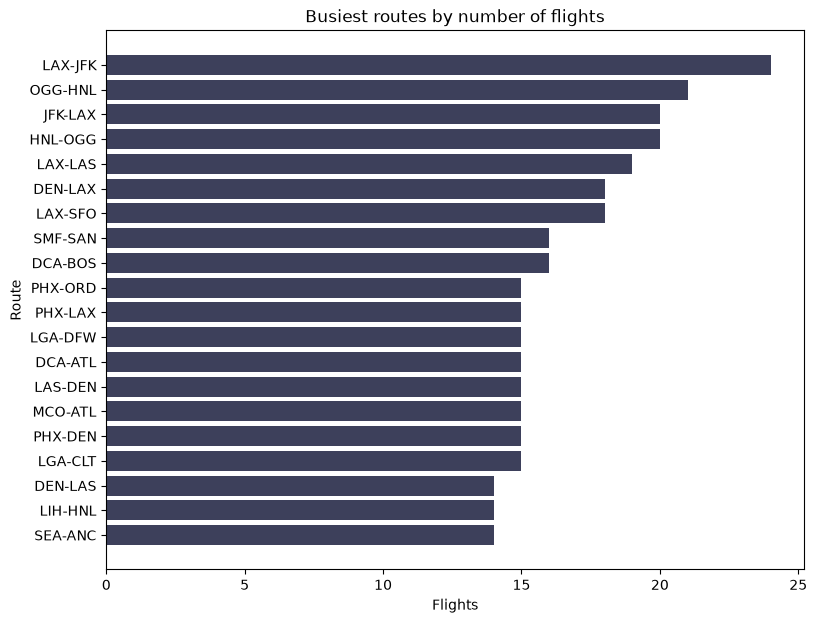

In [33]:
by_route = analysis.delays_by_route(df, min_flights=100).toPandas()
save_table(by_route, "delays_by_route")
busiest = advanced_analysis.busiest_routes_volume(df, top=40).toPandas()
save_table(busiest, "busiest_routes")
visualize.hbar_chart(busiest, "route", "flights",
    "Busiest routes by number of flights", "Route", "Flights",
    "busiest_routes.png", top=20)
maps.route_map(busiest)
busiest.head(10)

### 5.5 Delays by month (seasonal trend)

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/delays_by_month.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/delay_by_month.png
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/month_flights_vs_delay.png


,month,flights,avg_arr_delay,avg_dep_delay,delayed_pct,big_delay_pct,early_pct
0,1,717,10.35,14.56,25.24,10.18,58.72
1,2,709,-0.33,6.87,14.81,4.65,68.12
2,3,828,7.93,13.37,22.34,8.21,59.30
3,4,845,6.58,11.65,21.30,6.86,61.66
4,5,823,12.84,16.95,24.67,9.36,56.74
5,6,821,9.19,14.78,26.31,7.67,58.34
6,7,882,21.49,25.72,31.86,13.49,50.00
7,8,857,9.99,15.23,23.10,9.92,60.21
8,9,831,0.94,6.36,15.40,4.81,69.19
9,10,933,-3.62,2.76,11.90,3.11,73.85


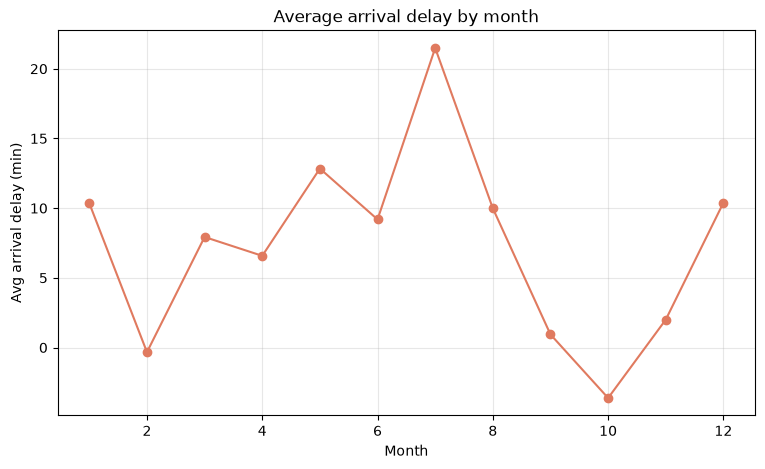

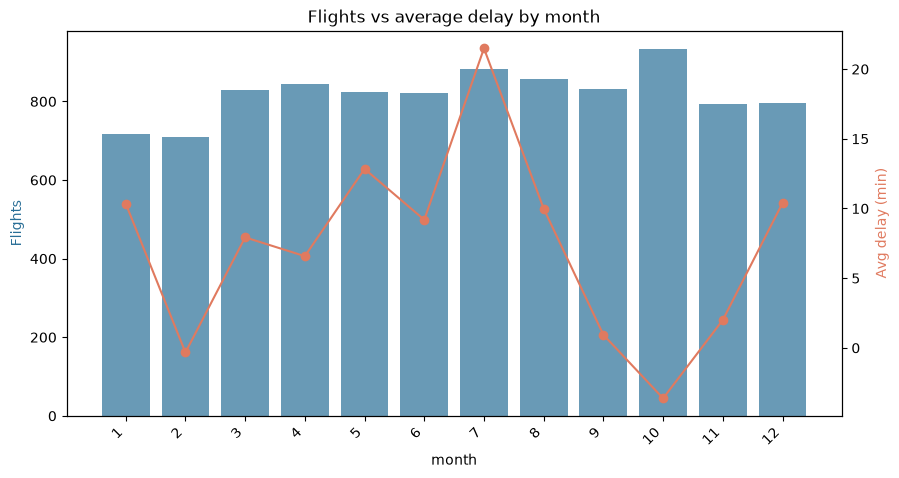

In [34]:
by_month = analysis.delays_by_month(df).toPandas()
save_table(by_month, "delays_by_month")
visualize.line_chart(by_month, "month", "avg_arr_delay",
    "Average arrival delay by month", "Month", "Avg arrival delay (min)",
    "delay_by_month.png")
visualize.dual_axis(by_month, "month", "flights", "avg_arr_delay",
    "Flights vs average delay by month", "Flights", "Avg delay (min)",
    "month_flights_vs_delay.png")
by_month

### 5.6 Delays by day of week

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/delays_by_day_of_week.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/delay_by_day_of_week.png


,day_of_week,flights,avg_arr_delay,avg_dep_delay,delayed_pct,big_delay_pct,early_pct
0,1,1529,5.11,10.74,20.08,6.34,64.16
1,2,1376,3.09,9.55,18.31,6.83,66.35
2,3,1298,4.64,9.89,18.72,6.70,64.10
3,4,1521,8.89,13.25,23.93,8.35,59.04
4,5,1437,9.98,14.89,24.08,9.39,58.94
5,6,1279,9.57,15.79,21.74,8.60,62.86
6,7,1395,10.04,14.91,23.51,8.39,58.57


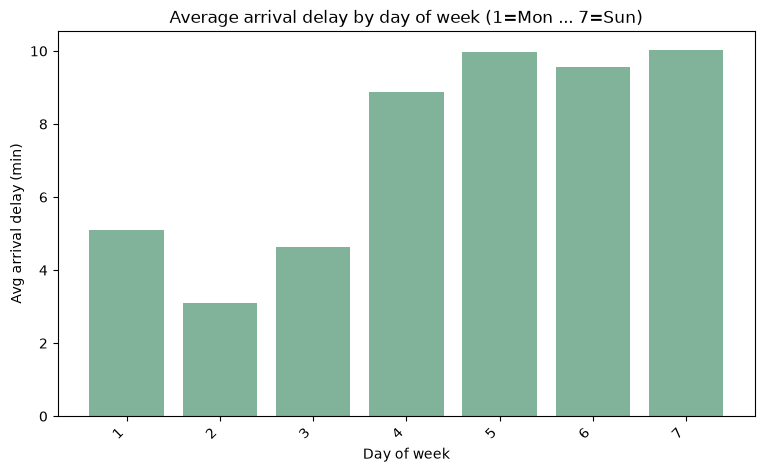

In [35]:
by_dow = analysis.delays_by_day_of_week(df).toPandas()
save_table(by_dow, "delays_by_day_of_week")
visualize.bar_chart(by_dow, "day_of_week", "avg_arr_delay",
    "Average arrival delay by day of week (1=Mon ... 7=Sun)",
    "Day of week", "Avg arrival delay (min)", "delay_by_day_of_week.png",
    color="#81b29a")
by_dow

### 5.7 Delays by hour of day

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/delays_by_hour.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/delay_by_hour.png


,dep_hour,flights,avg_arr_delay,avg_dep_delay,delayed_pct,big_delay_pct,early_pct
0,0,13,7.23,10.62,46.15,0.00,38.46
1,1,7,-11.57,3.57,14.29,0.00,85.71
2,2,2,-5.50,0.00,0.00,0.00,100.00
3,3,3,-11.00,-12.67,0.00,0.00,100.00
4,4,1,43.00,51.00,100.00,0.00,0.00
5,5,278,-1.81,5.44,10.07,3.60,76.98
6,6,681,0.56,5.70,12.92,4.70,73.42
7,7,689,4.55,9.94,14.80,6.10,69.23
8,8,667,-1.39,4.13,14.24,3.45,71.21
9,9,546,3.02,7.51,17.58,5.86,62.09


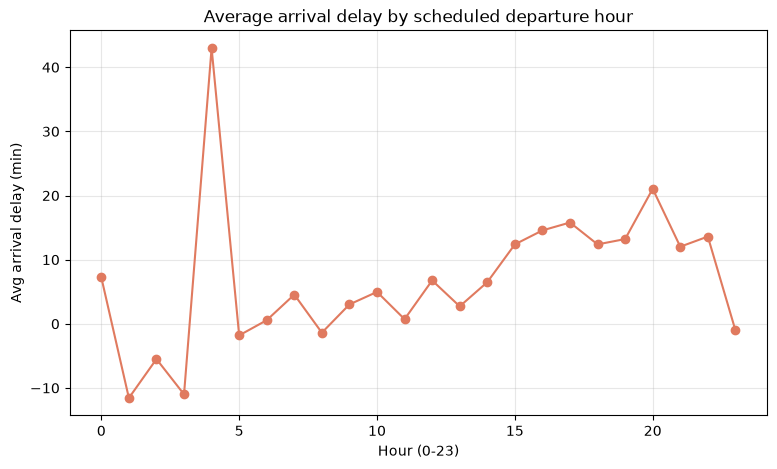

In [36]:
by_hour = analysis.delays_by_hour(df).toPandas()
save_table(by_hour, "delays_by_hour")
visualize.line_chart(by_hour, "dep_hour", "avg_arr_delay",
    "Average arrival delay by scheduled departure hour", "Hour (0-23)",
    "Avg arrival delay (min)", "delay_by_hour.png")
by_hour

### 5.8 Delays by season

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/delays_by_season.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/delay_by_season.png


,season,flights,avg_arr_delay,avg_dep_delay,delayed_pct,big_delay_pct,early_pct
0,Summer,2560,13.70,18.70,27.15,10.43,56.09
1,Autumn,2558,-0.40,5.66,15.01,4.46,69.98
2,Spring,2496,9.09,13.97,22.76,8.13,59.25
3,Winter,2221,6.96,12.48,21.21,8.24,62.45


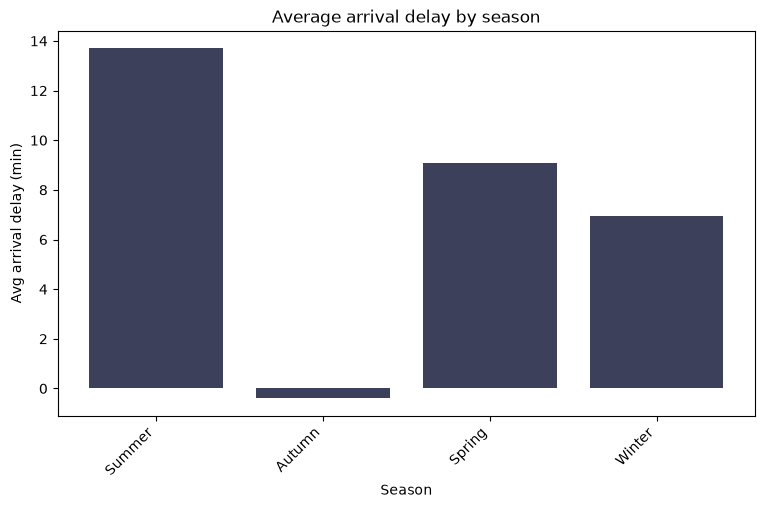

In [37]:
by_season = analysis.delays_by_season(df).toPandas()
save_table(by_season, "delays_by_season")
visualize.bar_chart(by_season, "season", "avg_arr_delay",
    "Average arrival delay by season", "Season", "Avg arrival delay (min)",
    "delay_by_season.png", color="#3d405b")
by_season

### 5.9 Delays by part of the day

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/delays_by_day_part.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/delay_by_day_part.png


,day_part,flights,avg_arr_delay,avg_dep_delay,delayed_pct,big_delay_pct,early_pct
0,Morning (6-12),3781,2.06,7.38,15.45,5.16,68.13
1,Afternoon (12-17),2957,8.51,13.65,23.13,8.12,60.50
2,Evening (17-21),2187,15.14,20.14,29.77,11.84,52.99
3,Late (21-24),606,11.00,18.08,26.90,10.40,55.78
4,Night (0-6),304,-1.62,5.55,11.84,3.29,75.66


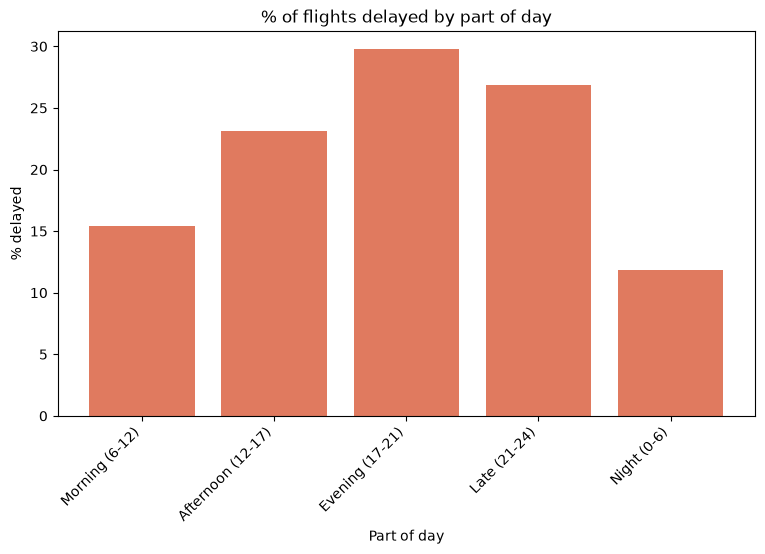

In [38]:
by_part = analysis.delays_by_day_part(df).toPandas()
save_table(by_part, "delays_by_day_part")
visualize.bar_chart(by_part, "day_part", "delayed_pct",
    "% of flights delayed by part of day", "Part of day", "% delayed",
    "delay_by_day_part.png", color="#e07a5f")
by_part

### 5.10 Delays by distance band (short vs long haul)

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/delays_by_distance_band.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/delay_by_distance.png


,distance_band,flights,avg_arr_delay,avg_dep_delay,delayed_pct,big_delay_pct,early_pct
0,Medium (600-1200),3670,7.53,12.80,22.89,8.50,60.63
1,Short (250-600),3125,7.39,11.91,20.06,7.58,64.10
2,Long (1200-2500),1744,7.44,15.13,22.42,7.17,59.92
3,Very short (<250mi),1112,7.77,11.85,20.41,7.55,63.13
4,Very long (2500+),184,-0.74,6.49,17.93,4.89,63.59


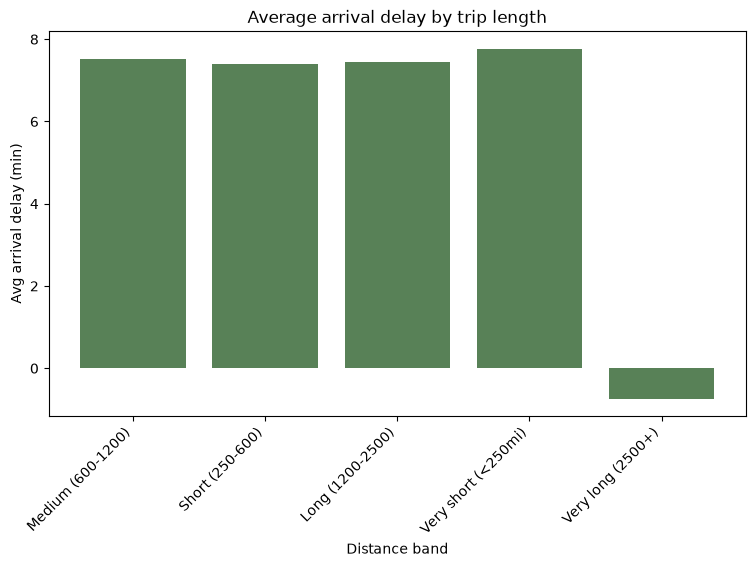

In [39]:
by_dist = analysis.delays_by_distance_band(df).toPandas()
save_table(by_dist, "delays_by_distance_band")
visualize.bar_chart(by_dist, "distance_band", "avg_arr_delay",
    "Average arrival delay by trip length", "Distance band",
    "Avg arrival delay (min)", "delay_by_distance.png", color="#588157")
by_dist

### 5.11 Weekend vs weekday  &  5.12 Red-eye vs daytime

In [40]:
wk = analysis.delays_weekend_vs_weekday(df).toPandas()
save_table(wk, "delays_weekend_vs_weekday")
re = analysis.delays_by_redeye(df).toPandas()
save_table(re, "delays_by_redeye")
print(wk[["kind","flights","avg_arr_delay","delayed_pct"]])
print(re[["kind","flights","avg_arr_delay","delayed_pct"]])

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/delays_weekend_vs_weekday.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/delays_by_redeye.csv
      kind  flights  avg_arr_delay  delayed_pct
0  Weekday     7161           6.42        21.11
1  Weekend     2674           9.81        22.66
      kind  flights  avg_arr_delay  delayed_pct
0  Daytime     9240           7.56        21.72
1  Red-eye      595           4.01        18.66


### 5.13 Delays by US state (choropleth MAP)

In [41]:
by_state = analysis.delays_by_state(df).toPandas()
save_table(by_state, "delays_by_state")
maps.state_choropleth(by_state, state_col="origin_state_nm", value_col="avg_arr_delay")
by_state.head(10)

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/delays_by_state.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/map_state_choropleth.html
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/map_state_choropleth.png


,origin_state_nm,flights,avg_arr_delay,avg_dep_delay,delayed_pct,big_delay_pct,early_pct
0,California,1055,5.43,11.13,19.15,6.45,64.17
1,Texas,1045,9.31,14.84,22.68,8.33,60.10
2,Florida,922,9.65,13.95,24.73,10.20,57.92
3,New York,549,1.17,8.99,18.21,6.38,68.12
4,Illinois,529,8.11,13.92,24.76,8.70,59.36
5,Georgia,519,6.37,10.39,19.65,8.29,65.13
6,Colorado,462,9.73,14.69,27.71,7.14,56.28
7,North Carolina,446,12.90,18.14,26.91,11.21,58.74
8,Arizona,325,6.36,12.05,20.31,6.15,59.69
9,Virginia,313,8.99,14.82,23.96,8.95,60.38


### 5.14 Delay bands (how late, in buckets)

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/delay_band_counts.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/delay_bands_pie.png


,delay_band,flights
0,Early,6092
1,On time,1625
2,Minor (15-60m),1351
3,Major (1-3h),619
4,Severe (3h+),148


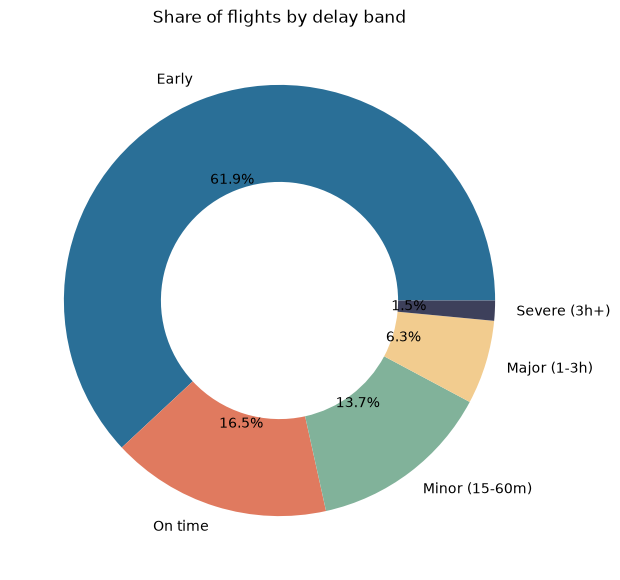

In [42]:
bands = analysis.delay_band_counts(df).toPandas()
save_table(bands, "delay_band_counts")
visualize.pie_chart(bands, "delay_band", "flights",
    "Share of flights by delay band", "delay_bands_pie.png")
bands

### 5.15 What causes the delays?

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/delay_causes.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/delay_causes_pie.png
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/delay_cause_frequency.csv


saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/cause_share_by_month.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/cause_by_month_stacked.png


,cause,pct_of_flights
0,carrier_delay,11.54
1,weather_delay,1.43
2,nas_delay,10.73
3,security_delay,0.06
4,late_aircraft_delay,10.83


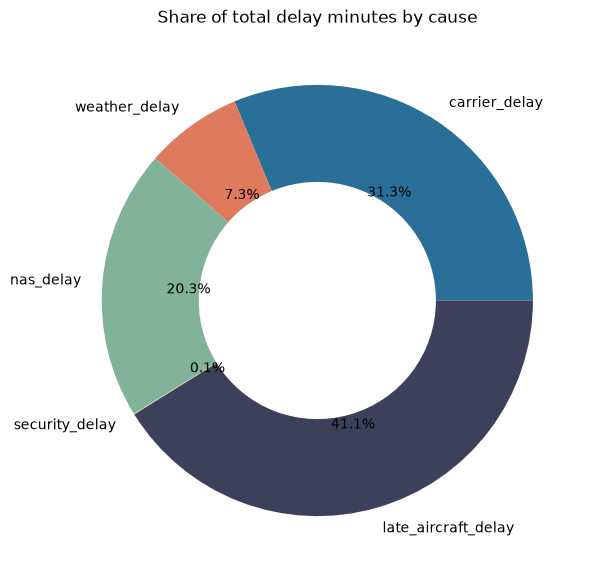

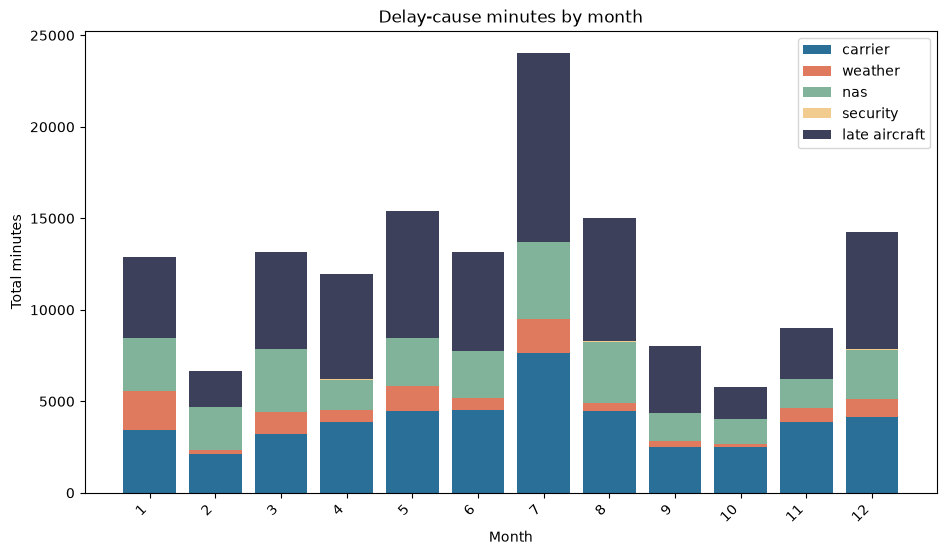

In [43]:
# total minutes per cause
causes = analysis.delay_cause_totals(df).toPandas().T.reset_index()
causes.columns = ["cause","minutes"]
save_table(causes, "delay_causes")
visualize.pie_chart(causes, "cause", "minutes",
    "Share of total delay minutes by cause", "delay_causes_pie.png")

# how often each cause appears (% of flights)
freq = analysis.delay_cause_frequency(df).toPandas().T.reset_index()
freq.columns = ["cause","pct_of_flights"]
save_table(freq, "delay_cause_frequency")

# cause mix by month (stacked)
cmonth = analysis.cause_share_by_month(df).toPandas()
save_table(cmonth, "cause_share_by_month")
visualize.stacked_bar(cmonth, "month",
    ["carrier_delay","weather_delay","nas_delay","security_delay","late_aircraft_delay"],
    "Delay-cause minutes by month", "Month", "Total minutes",
    "cause_by_month_stacked.png",
    labels=["carrier","weather","nas","security","late aircraft"])
freq

### 5.16 Cancellations and diversions (uses the RAW data)

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/cancellation_overview.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/cancellations_by_reason.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/cancellations_by_airline.csv
   total_flights  cancelled_pct  diverted_pct
0          10000           1.22          0.42
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/cancellations_by_reason.png


,cancellation_code,cancellations
0,B,74
1,A,31
2,C,17


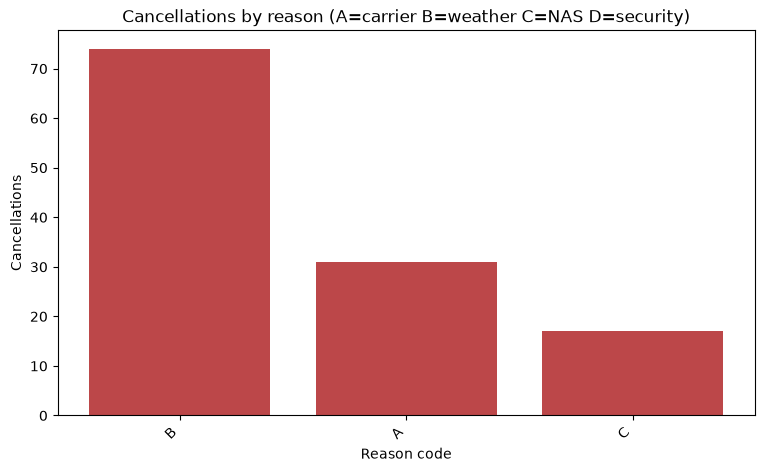

In [44]:
overview = analysis.cancellation_overview(df_raw).toPandas()
save_table(overview, "cancellation_overview")
by_reason = analysis.cancellations_by_reason(df_raw).toPandas()
save_table(by_reason, "cancellations_by_reason")
canc_air = analysis.cancellations_by_airline(df_raw).toPandas()
save_table(canc_air, "cancellations_by_airline")
print(overview)
visualize.bar_chart(by_reason, "cancellation_code", "cancellations",
    "Cancellations by reason (A=carrier B=weather C=NAS D=security)",
    "Reason code", "Cancellations", "cancellations_by_reason.png", color="#bc4749")
by_reason

## 6. Deeper / statistical analysis

### 6.1 Distribution & percentiles of arrival delay

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/delay_describe.csv


saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/delay_percentiles.csv


saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/delay_histogram.png
   count  mean  stddev   min    max
0   9835  7.34   52.01 -78.0  995.0
  percentile  minutes
0        P10    -23.0
1        P25    -15.0
2        P50     -6.0
3        P75     10.0
4        P90     46.0
5        P95     87.0
6        P99    215.0


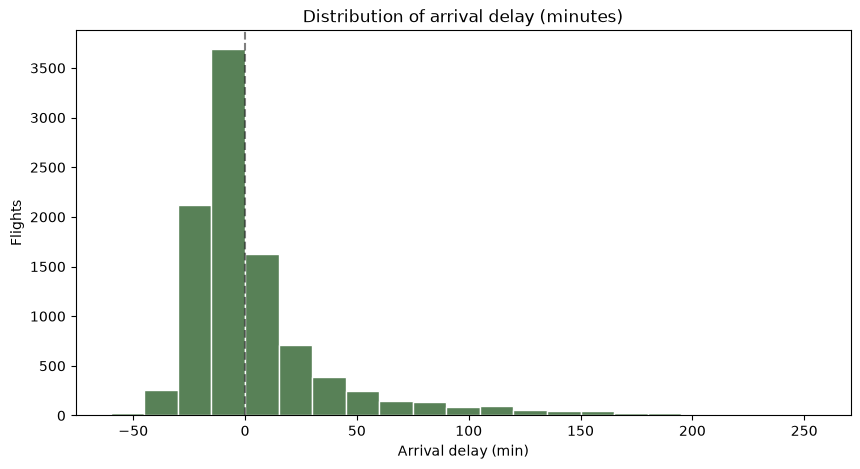

In [45]:
desc = advanced_analysis.delay_describe(df).toPandas()
save_table(desc, "delay_describe")
pct = advanced_analysis.delay_percentiles(df).toPandas()
save_table(pct, "delay_percentiles")
hist = advanced_analysis.delay_histogram(df).toPandas()
visualize.histogram(hist, "bin", "flights",
    "Distribution of arrival delay (minutes)", "Arrival delay (min)",
    "Flights", "delay_histogram.png")
print(desc); print(pct)

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/delay_boxplot_season.png


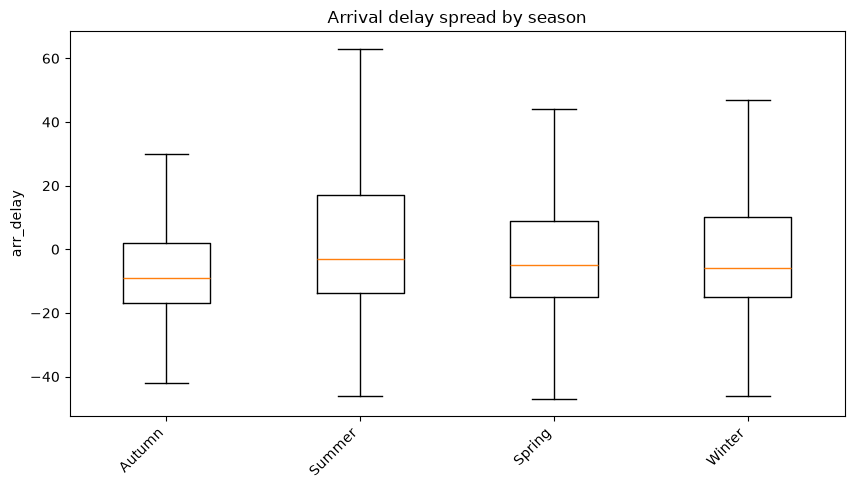

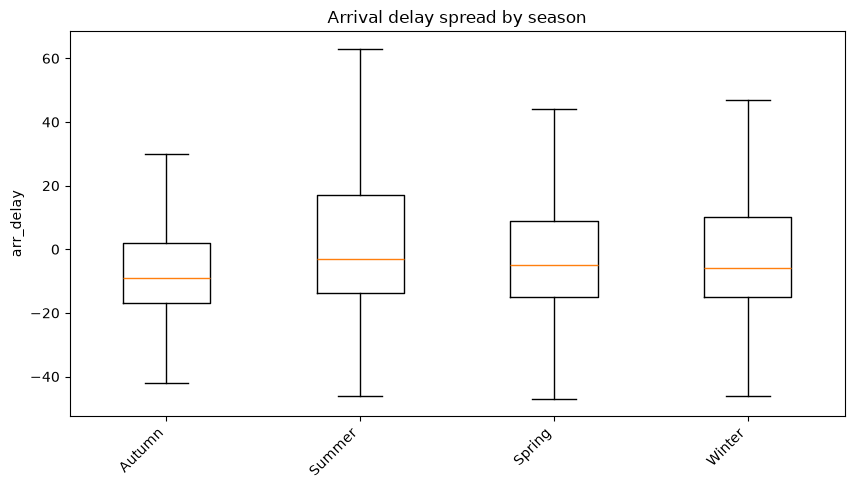

In [49]:
# boxplot of delay by season (uses a sample of raw rows)
season_sample = df.select("season","arr_delay").sample(False, 0.2, seed=1).toPandas()
visualize.boxplot_by_group(season_sample, "season", "arr_delay",
    "Arrival delay spread by season", "delay_boxplot_season.png")

### 6.2 Correlation between numeric columns

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/correlation_matrix.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/correlation_heatmap.png


,dep_delay,arr_delay,taxi_out,taxi_in,distance,air_time,crs_elapsed_time,dep_hour
dep_delay,1.00,0.96,0.04,0.02,0.01,0.02,0.02,0.10
arr_delay,0.96,1.00,0.19,0.14,-0.01,0.01,-0.01,0.10
taxi_out,0.04,0.19,1.00,0.03,0.05,0.07,0.09,0.03
taxi_in,0.02,0.14,0.03,1.00,0.04,0.05,0.07,-0.03
distance,0.01,-0.01,0.05,0.04,1.00,0.98,0.98,-0.01
air_time,0.02,0.01,0.07,0.05,0.98,1.00,0.99,-0.02
crs_elapsed_time,0.02,-0.01,0.09,0.07,0.98,0.99,1.00,-0.02
dep_hour,0.10,0.10,0.03,-0.03,-0.01,-0.02,-0.02,1.00


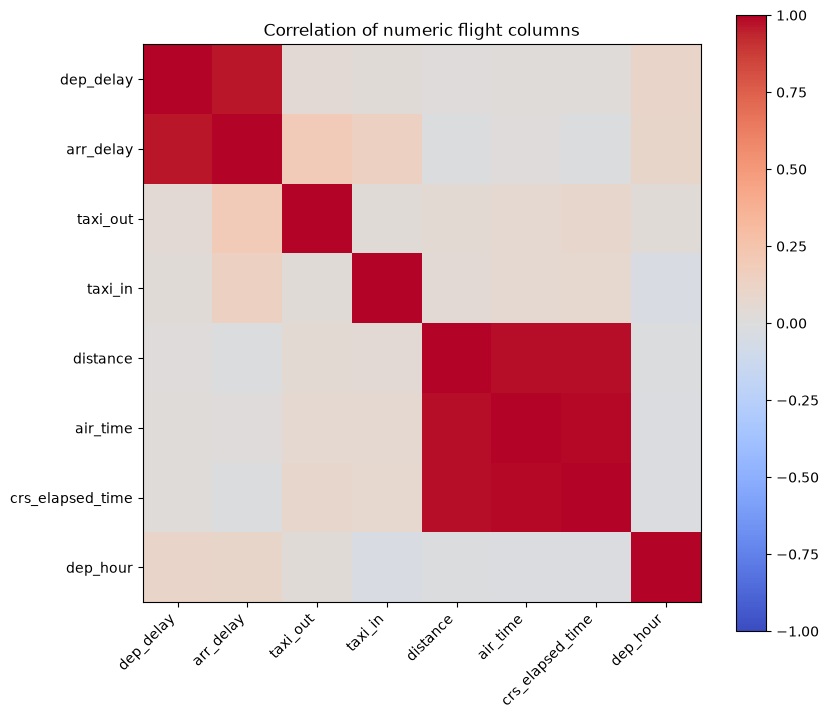

In [50]:
corr = advanced_analysis.correlation_matrix(df)
save_table(corr.reset_index(), "correlation_matrix")
visualize.correlation_heatmap(corr, "Correlation of numeric flight columns",
    "correlation_heatmap.png")
corr.round(2)

### 6.3 Delay propagation: does leaving late mean arriving late?

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/propagation_scatter.png
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/propagation_by_band.csv


,dep_band,flights,avg_dep_delay,avg_arr_delay,avg_minutes_recovered
0,30-60 late,605,42.6,37.6,4.9
1,120+ late,309,220.4,217.1,3.3
2,15-30 late,664,21.4,15.9,5.5
3,1-15 late,1595,6.2,0.9,5.3
4,60-120 late,463,85.0,82.0,3.1
5,On time / early,6199,-5.2,-10.9,5.7


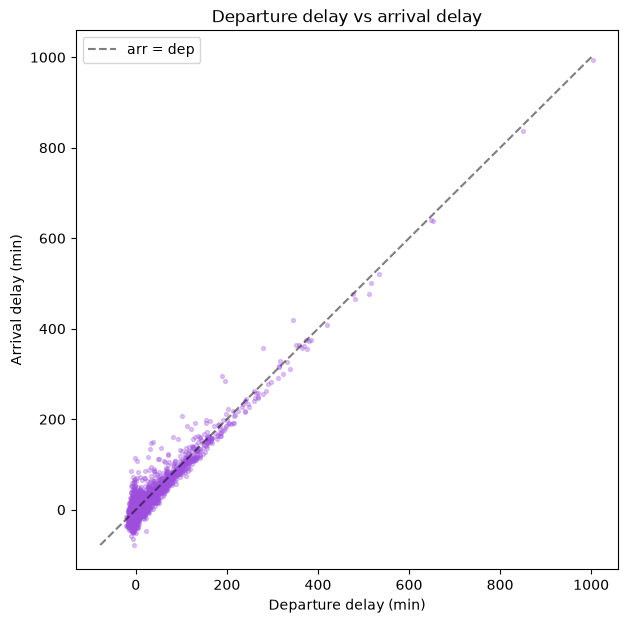

In [51]:
scat = advanced_analysis.propagation_scatter_sample(df, 5000)
visualize.scatter(scat, "dep_delay", "arr_delay",
    "Departure delay vs arrival delay", "Departure delay (min)",
    "Arrival delay (min)", "propagation_scatter.png")
prop = advanced_analysis.propagation_by_depdelay_band(df).toPandas()
save_table(prop, "propagation_by_band")
prop

### 6.4 Two-way heatmaps

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/heatmap_hour_dow.png


saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/heatmap_airline_month.png


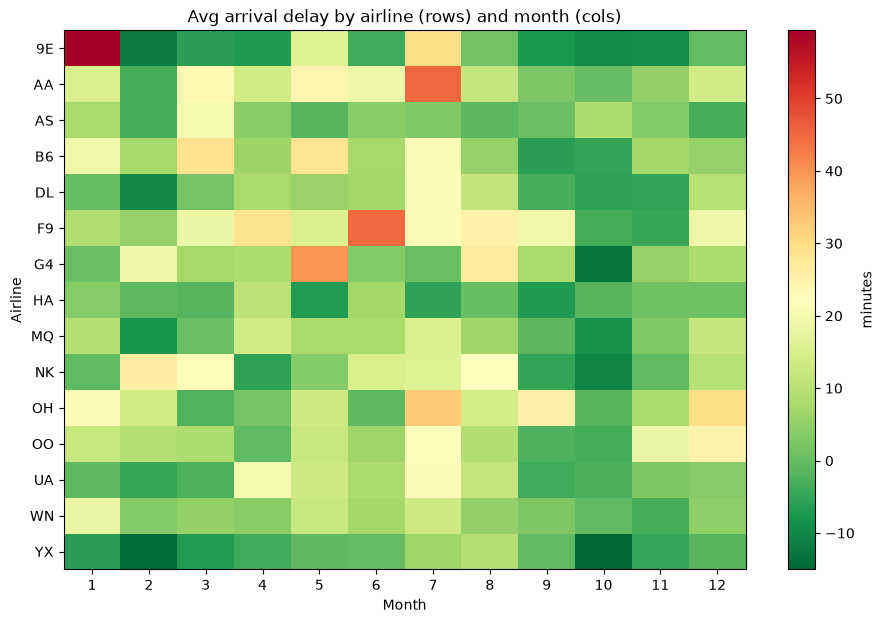

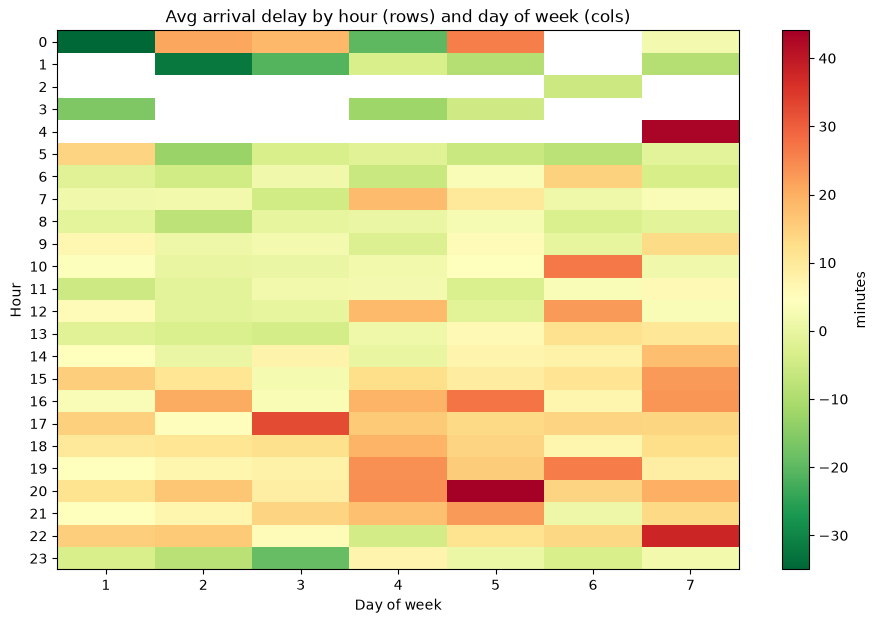

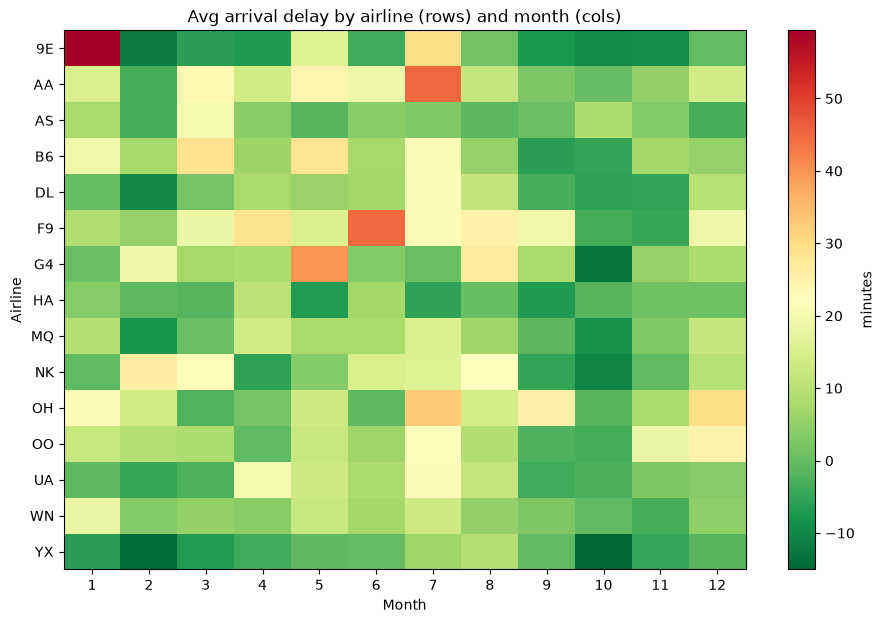

In [52]:
hd = advanced_analysis.heatmap_hour_vs_dow(df)
visualize.heatmap(hd, "Avg arrival delay by hour (rows) and day of week (cols)",
    "heatmap_hour_dow.png", xlabel="Day of week", ylabel="Hour")
am = advanced_analysis.heatmap_airline_vs_month(df)
visualize.heatmap(am, "Avg arrival delay by airline (rows) and month (cols)",
    "heatmap_airline_month.png", xlabel="Month", ylabel="Airline")

### 6.5 Hub / network analysis

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/airport_traffic.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/airport_traffic.png


,airport,departures,arrivals,total_movements
0,ATL,487,479,966
1,DFW,428,439,867
2,DEN,408,390,798
3,ORD,387,365,752
4,CLT,314,281,595
5,PHX,288,274,562
6,LAX,278,269,547
7,LAS,230,277,507
8,LGA,229,210,439
9,MCO,221,211,432


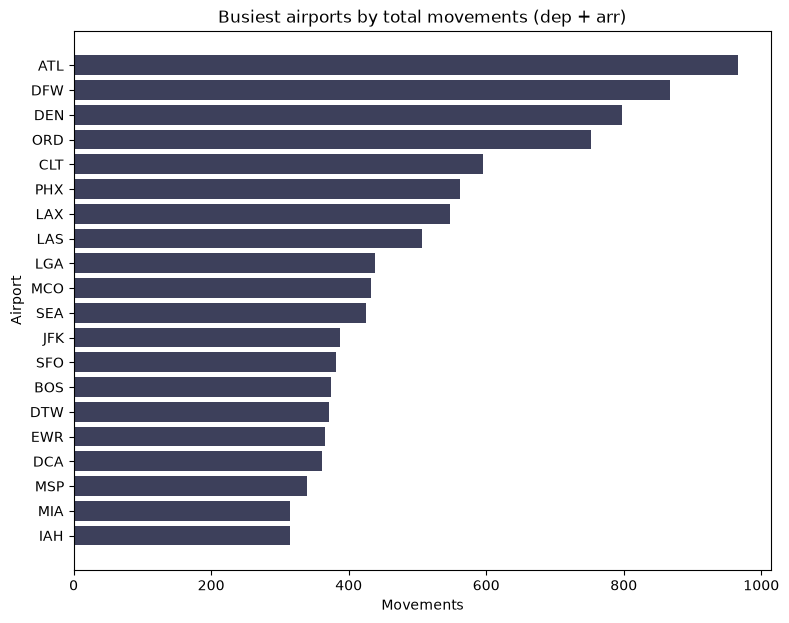

In [53]:
traffic = advanced_analysis.airport_traffic(df, top=20).toPandas()
save_table(traffic, "airport_traffic")
visualize.hbar_chart(traffic, "airport", "total_movements",
    "Busiest airports by total movements (dep + arr)", "Airport",
    "Movements", "airport_traffic.png", top=20)
traffic.head(10)

### 6.6 Airline scorecard + radar

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/airline_scorecard.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/airline_radar.png


,op_unique_carrier,flights,on_time_pct,avg_arr_delay,p90_delay,big_delay_pct
0,DL,1443,82.5,3.5,36.0,6.58
1,OO,1067,80.3,9.1,45.0,7.69
2,WN,1993,78.7,6.0,39.0,6.02
3,UA,1015,77.7,5.4,45.0,7.39
4,AA,1359,72.0,14.7,69.0,11.70


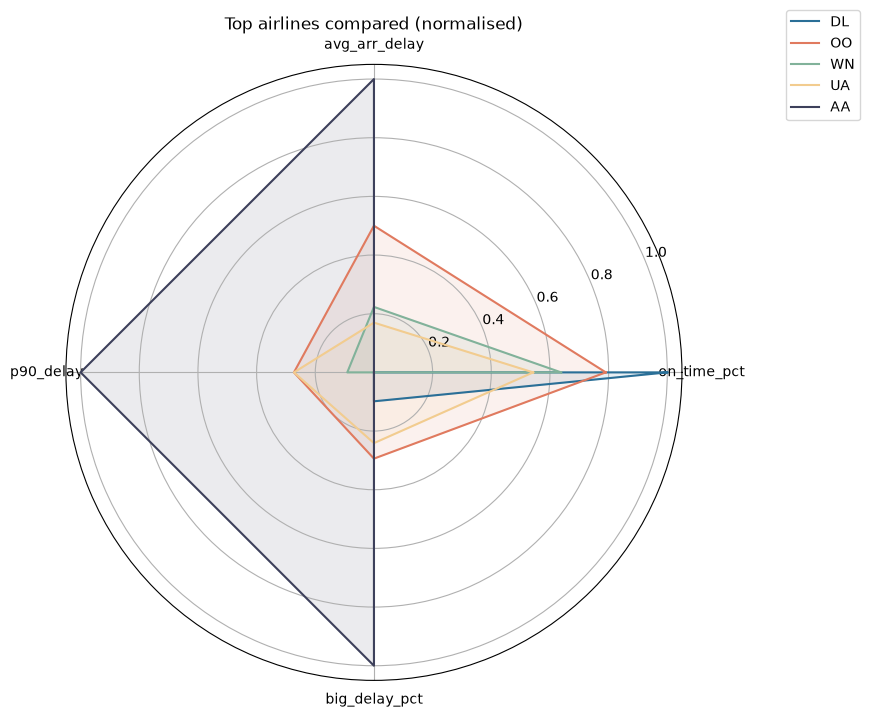

In [54]:
score = advanced_analysis.airline_scorecard(df, min_flights=1000).toPandas()
save_table(score, "airline_scorecard")
visualize.radar_chart(score.sort_values("on_time_pct", ascending=False),
    "op_unique_carrier", ["on_time_pct","avg_arr_delay","p90_delay","big_delay_pct"],
    "Top airlines compared (normalised)", "airline_radar.png", top=5)
score

## 7. Predictive modelling (Spark MLlib)
We only use information known **before** the flight leaves (airline, origin,
dest, month, day, hour, distance, season, day-part) – no cheating with columns
that are only known after landing.

> On the full dataset this is the slow part. If it takes too long, train on a
> sub-sample with `prepare_model_data(df, max_rows=500000)`.

In [55]:
model_data = modeling.prepare_model_data(df)   # add max_rows=... to subsample
model_data = model_data.cache()
print("rows used for modelling:", model_data.count())

rows used for modelling: 9835


### 7.1 Classification – will the flight be delayed (15+ min)?

26/06/26 23:54:22 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/model_metrics.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/model_auc.png


,AUC,accuracy,f1
LogisticRegression,0.5980,0.7692,0.7016
RandomForest,0.6325,0.7817,0.6859


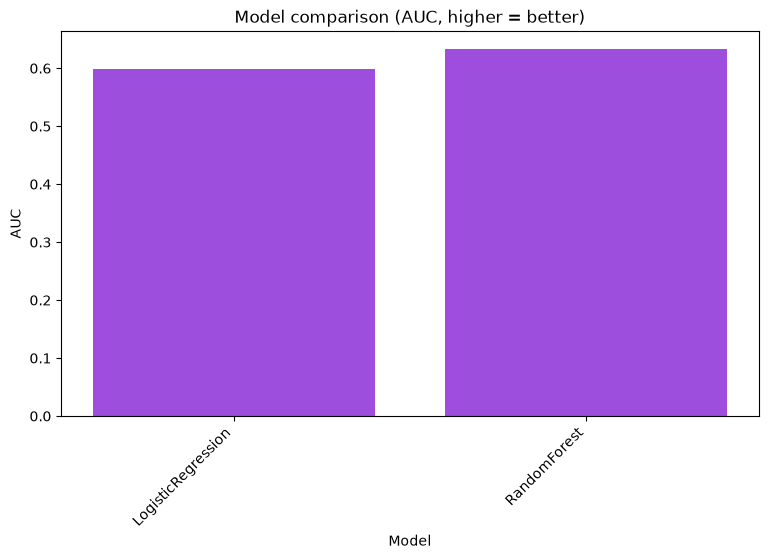

In [56]:
clf = modeling.train_classifiers(model_data)
metrics = pd.DataFrame(clf["metrics"]).T
save_table(metrics.reset_index().rename(columns={"index":"model"}), "model_metrics")
visualize.bar_chart(metrics.reset_index(), "index", "AUC",
    "Model comparison (AUC, higher = better)", "Model", "AUC",
    "model_auc.png", color="#9d4edd")
metrics

   label  prediction     n
0      1         0.0   438
1      0         0.0  1568
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/feature_importance.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/feature_importance.png


,feature,importance
524,f570,0.130439
516,f563,0.093255
518,f565,0.049704
513,f560,0.043675
521,f568,0.036046
511,f559,0.032692
525,f571,0.028289
112,f2,0.027805
522,f569,0.018041
519,f566,0.016873


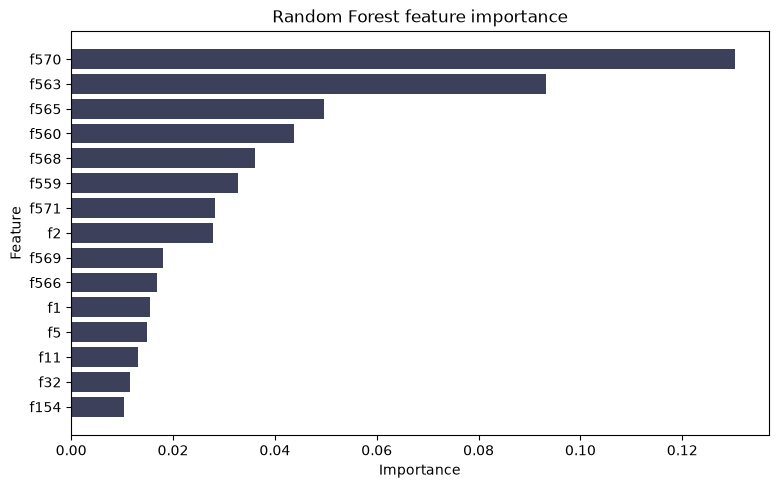

In [57]:
# confusion matrix + feature importance for the Random Forest
cm = modeling.confusion_counts(clf["models"]["RandomForest"], clf["test"])
print(cm)
imp = modeling.feature_importance(clf["models"]["RandomForest"], top=15)
save_table(imp, "feature_importance")
visualize.hbar_chart(imp, "feature", "importance",
    "Random Forest feature importance", "Feature", "Importance",
    "feature_importance.png", top=15)
imp

### 7.2 Regression – how many minutes late?

In [58]:
reg = modeling.train_regressor(model_data)
print("Regression metrics:", reg["metrics"])
pd.DataFrame([reg["metrics"]])

26/06/26 23:56:19 WARN DAGScheduler: Broadcasting large task binary with size 1097.2 KiB


Regression metrics: {'RMSE': 53.111, 'MAE': 27.205, 'R2': -0.0036}


,RMSE,MAE,R2
0,53.111,27.205,-0.0036


## 8. Clustering – grouping airports into performance segments
We build a profile for each airport (how busy, average delay, % delayed, taxi-out
time, % long-haul) and let K-Means find natural groups.

26/06/27 00:00:57 WARN CacheManager: Asked to cache already cached data.


airports profiled: 48
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/kmeans_silhouette.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/kmeans_silhouette.png


,k,silhouette
0,2,0.3915
1,3,0.4328
2,4,0.4648
3,5,0.4279
4,6,0.3004


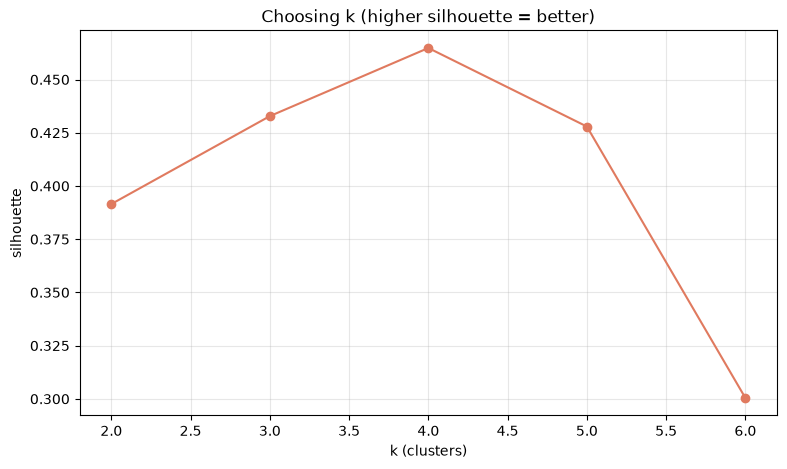

In [62]:
min_flights = 50 if USE_SAMPLE else 1000
profiles = clustering.build_airport_profiles(df, min_flights=min_flights).cache()
profile_count = profiles.count()
print("airports profiled:", profile_count)
if profile_count < 2:
    raise ValueError(f"Not enough airports for clustering (got {profile_count}). Lower min_flights or use the full dataset.")
k_values = tuple(k for k in (2, 3, 4, 5, 6) if k < profile_count)
k_table = clustering.choose_k(profiles, k_values=k_values)
save_table(k_table, "kmeans_silhouette")
visualize.line_chart(k_table, "k", "silhouette",
    "Choosing k (higher silhouette = better)", "k (clusters)", "silhouette",
    "kmeans_silhouette.png")
k_table

saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/airport_clusters.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/tables/cluster_summary.csv
saved -> /Users/Mehr/Desktop/code/26/college/assignment 2/outputs/figures/airport_clusters.png


,cluster,flights,avg_arr_delay,delayed_pct,avg_taxi_out,pct_longhaul,n_airports
0,0,134.40,11.47,26.29,17.37,16.98,10
1,1,188.07,5.94,21.45,20.58,36.70,14
2,2,404.80,10.92,25.53,19.74,15.32,5
3,3,86.05,3.61,17.03,14.35,17.14,19


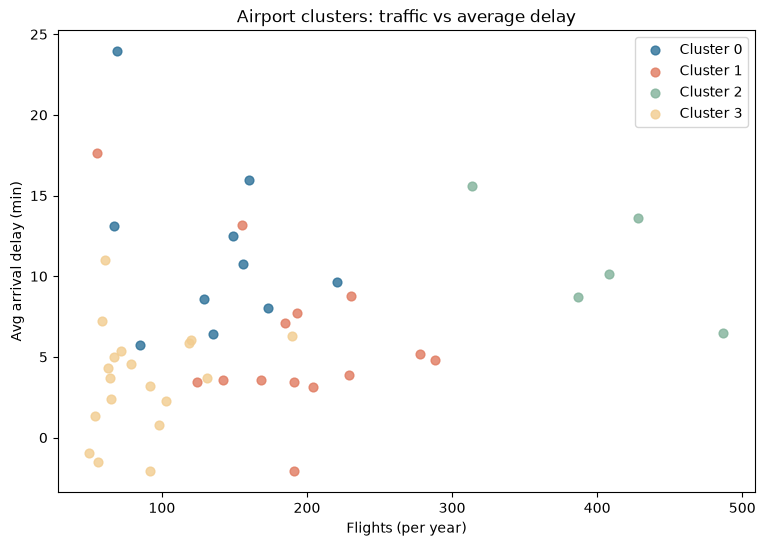

In [63]:
cluster_k = min(4, profile_count - 1)
clustered = clustering.cluster_airports(profiles, k=cluster_k)
save_table(clustered, "airport_clusters")
summary = clustering.cluster_profiles_summary(clustered)
save_table(summary, "cluster_summary")
visualize.cluster_scatter(clustered, "flights", "avg_arr_delay", "cluster",
    "Airport clusters: traffic vs average delay", "Flights (per year)",
    "Avg arrival delay (min)", "airport_clusters.png")
summary

## 9. Stop Spark

In [64]:
spark.stop()
print("done - figures in outputs/figures, tables in outputs/tables")

done - figures in outputs/figures, tables in outputs/tables
